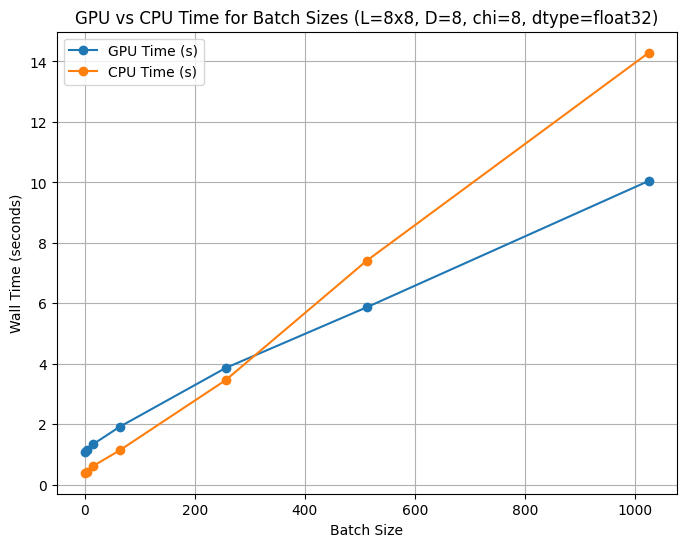

In [2]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 8, 8

timing_file = f'./{Lx}x{Ly}_D={D}_chi={chi}_timing_results_float32.npy'
data = np.load(timing_file, allow_pickle=True).item()
batch_sizes = data['batch_sizes']
GPU_times = data['GPU_times']
CPU_times = data['CPU_times']

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, GPU_times, marker='o', label='GPU Time (s)')
plt.plot(batch_sizes, CPU_times, marker='o', label='CPU Time (s)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'GPU vs CPU Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype=float32)')
plt.legend()
plt.grid(True)

Intel i7-12700K CPU time:
[0.45257043838500977, 0.49173641204833984, 0.9624102115631104, 2.4793105125427246, 4.691090822219849, 13.49692988395691]


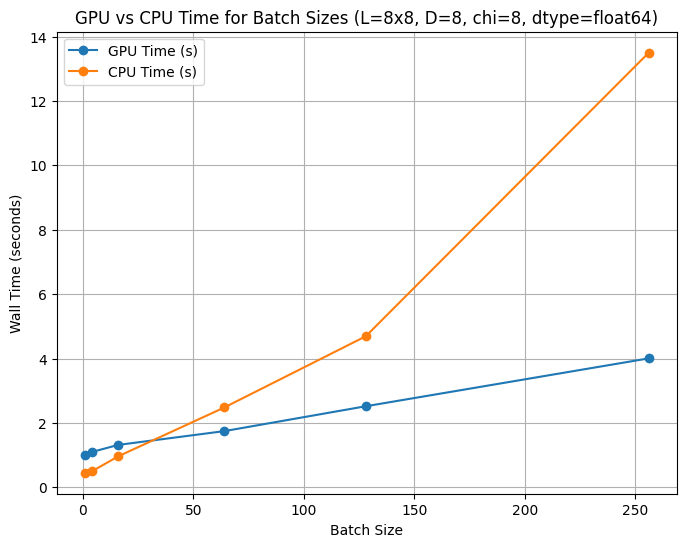

In [8]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 8, 8

dtype = 'float64'
timing_file = f'./{Lx}x{Ly}_D={D}_chi={chi}_timing_results_{dtype}.npy'
data = np.load(timing_file, allow_pickle=True).item()
batch_sizes = data['batch_sizes']
GPU_times = data['GPU_times']
CPU_times = data['CPU_times']
print('Intel i7-12700K CPU time:')
print(CPU_times)

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, GPU_times, marker='o', label='GPU Time (s)')
plt.plot(batch_sizes, CPU_times, marker='o', label='CPU Time (s)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'GPU vs CPU Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
plt.grid(True)

Intel i7-12700K CPU time:
[0.47966670989990234, 0.757176399230957, 1.9269301891326904, 5.080467700958252, 19.40966296195984, 38.52197074890137]


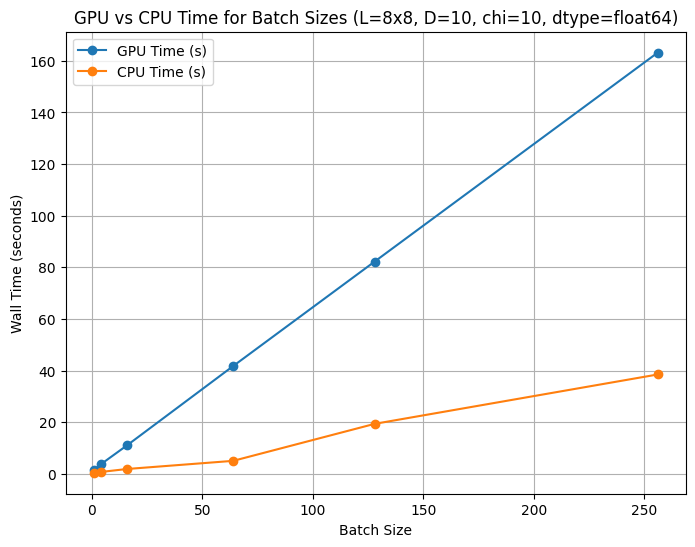

In [1]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 10, 10

dtype = 'float64'
timing_file = f'../data/{Lx}x{Ly}_D={D}_chi={chi}_timing_results_{dtype}.npy'
data = np.load(timing_file, allow_pickle=True).item()
batch_sizes = data['batch_sizes']
GPU_times = data['GPU_times']
CPU_times = data['CPU_times']
print('Intel i7-12700K CPU time:')
print(CPU_times)

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, GPU_times, marker='o', label='GPU Time (s)')
plt.plot(batch_sizes, CPU_times, marker='o', label='CPU Time (s)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'GPU vs CPU Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
plt.grid(True)

{'label': 'default', 'batch_sizes': [1, 2, 4, 8, 16, 32, 64, 128], 'gpu_times': [1.5902412109375, 2.247922607421875, 3.55723388671875, 6.08938916015625, 11.236857421875, 21.96363671875, 41.89646875, 83.0362109375], 'cpu_times': [0.3606459220027318, 0.4351072189892875, 0.6341556999977911, 1.0218548809934873, 1.7716254970000591, 3.1712886070017703, 5.670972694992088, 16.826704425999196]}
{'label': 'size_aware', 'batch_sizes': [1, 2, 4, 8, 16, 32, 64, 128], 'gpu_times': [1.129634765625, 1.4105682373046875, 1.601091552734375, 2.208198974609375, 3.565794189453125, 6.1638603515625, 11.104125, 20.912333984375], 'cpu_times': [0.37110641099570785, 0.4304676609899616, 0.5616737459931755, 0.8689174939936493, 1.4842160219996003, 3.0967731310083764, 5.680152262997581, 15.771206285993685]}
{'label': 'size_aware+syevBatched_eigh', 'batch_sizes': [1, 2, 4, 8, 16, 32, 64, 128, 256, 512], 'gpu_times': [1.0911763916015624, 1.1843983154296875, 1.497100341796875, 1.60226953125, 2.1032080078125, 3.276232666

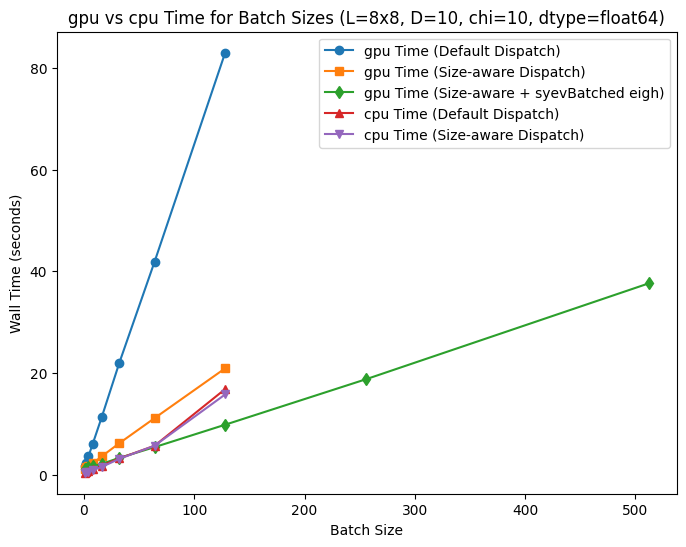

In [6]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 10, 10

dtype = 'float64'
timing_file_default = f'../data/{Lx}x{Ly}_D={D}_chi={chi}_default_{dtype}.npy'
timing_file_size_aware = f'../data/{Lx}x{Ly}_D={D}_chi={chi}_MAGMA_eigh_{dtype}.npy'
timing_file_batched_eigh = f'../data/{Lx}x{Ly}_D={D}_chi={chi}_syevBatched_eigh_{dtype}.npy'
default_data = np.load(timing_file_default, allow_pickle=True).item()['default']
size_aware_data = np.load(timing_file_size_aware, allow_pickle=True).item()['size_aware+MAGMA_eigh']
batched_eigh_data = np.load(timing_file_batched_eigh, allow_pickle=True).item()['size_aware+syevBatched_eigh']
print(default_data)
print(size_aware_data)
print(batched_eigh_data)
#plot default vs size-aware dispatch for gpu and cpu times
batch_sizes_default = default_data['batch_sizes']
batch_sizes_size_aware = size_aware_data['batch_sizes']
batch_sizes_batched_eigh = batched_eigh_data['batch_sizes']
gpu_times_default = default_data['gpu_times']
cpu_times_default = default_data['cpu_times']
gpu_times_size_aware = size_aware_data['gpu_times']
cpu_times_size_aware = size_aware_data['cpu_times']
gpu_times_batched_eigh = batched_eigh_data['gpu_times']
# cpu_times_batched_eigh = batched_eigh_data['cpu_times']
print('Intel i7-12700K cpu time:')
print('Default dispatch:', cpu_times_default)
print('Size-aware dispatch:', cpu_times_size_aware)
# print('Batched eigh dispatch:', cpu_times_batched_eigh)

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes_default, gpu_times_default, marker='o', label='gpu Time (Default Dispatch)')
plt.plot(batch_sizes_size_aware, gpu_times_size_aware, marker='s', label='gpu Time (Size-aware Dispatch)')
plt.plot(batch_sizes_batched_eigh, gpu_times_batched_eigh, marker='d', label='gpu Time (Size-aware + syevBatched eigh)')
plt.plot(batch_sizes_default, cpu_times_default, marker='^', label='cpu Time (Default Dispatch)')
plt.plot(batch_sizes_size_aware, cpu_times_size_aware, marker='v', label='cpu Time (Size-aware Dispatch)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'gpu vs cpu Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
# plt.grid(True)

{'size_aware+syevBatched_eigh': {'label': 'size_aware+syevBatched_eigh', 'batch_sizes': [1, 2, 4, 8, 16, 32, 64, 128, 256], 'gpu_times': [1.1808509521484376, 1.2568299560546874, 1.4771158447265624, 1.5413360595703125, 2.14312255859375, 3.267798095703125, 5.47102392578125, 10.592109375, 19.14012890625], 'cpu_times': [0.4186681859999979, 0.5003464509999986, 0.6717612770000017, 1.0114424900000003, 1.8504720330000026, 3.298211325000011, 6.104753969000001, 17.502803922, 31.20512054499997]}}
Intel i7-12700K cpu time:
Size-aware dispatch: [0.4186681859999979, 0.5003464509999986, 0.6717612770000017, 1.0114424900000003, 1.8504720330000026, 3.298211325000011, 6.104753969000001, 17.502803922, 31.20512054499997]


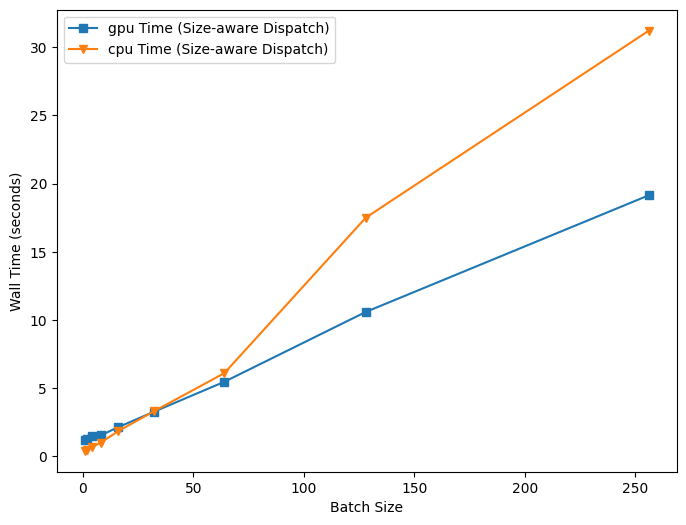

In [2]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 10, 10

dtype = 'float64'
timing_file = f'../data/{Lx}x{Ly}_D={D}_chi={chi}_syevBatched_eigh_{dtype}.npy'
data = np.load(timing_file, allow_pickle=True).item()
print(data)
size_aware_data = data['size_aware+syevBatched_eigh']
#plot default vs size-aware dispatch for gpu and cpu times
batch_sizes = size_aware_data['batch_sizes']
gpu_times_size_aware = size_aware_data['gpu_times']
cpu_times_size_aware = size_aware_data['cpu_times']
print('Intel i7-12700K cpu time:')
# print('Default dispatch:', cpu_times_default)
print('Size-aware dispatch:', cpu_times_size_aware)

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, gpu_times_size_aware, marker='s', label='gpu Time (Size-aware Dispatch)')
plt.plot(batch_sizes, cpu_times_size_aware, marker='v', label='cpu Time (Size-aware Dispatch)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
# plt.title(f'gpu vs cpu Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
# plt.grid(True)

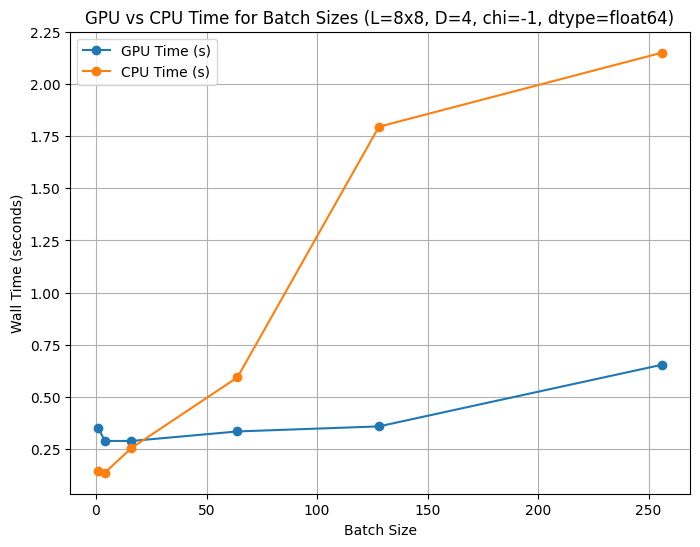

In [5]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 8, 8
D, chi = 4, -1

dtype = 'float64'
timing_file = f'./{Lx}x{Ly}_D={D}_chi={chi}_timing_results_{dtype}.npy'
data = np.load(timing_file, allow_pickle=True).item()
batch_sizes = data['batch_sizes']
GPU_times = data['GPU_times']
CPU_times = data['CPU_times']

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, GPU_times, marker='o', label='GPU Time (s)')
plt.plot(batch_sizes, CPU_times, marker='o', label='CPU Time (s)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'GPU vs CPU Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
plt.grid(True)

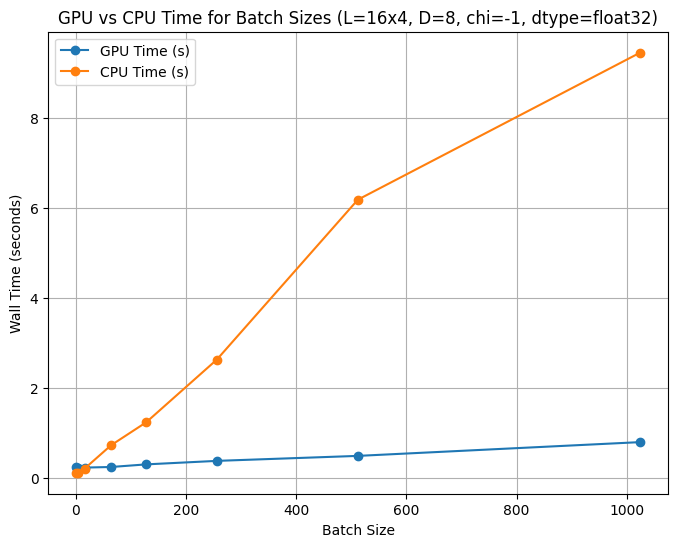

In [12]:
from matplotlib import pyplot as plt
import numpy as np

Lx, Ly = 16, 4
D, chi = 8, -1

dtype = 'float32'
timing_file = f'./{Lx}x{Ly}_D={D}_chi={chi}_timing_results_{dtype}.npy'
data = np.load(timing_file, allow_pickle=True).item()
batch_sizes = data['batch_sizes']
GPU_times = data['GPU_times']
CPU_times = data['CPU_times']

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, GPU_times, marker='o', label='GPU Time (s)')
plt.plot(batch_sizes, CPU_times, marker='o', label='CPU Time (s)')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Wall Time (seconds)')
plt.title(f'GPU vs CPU Time for Batch Sizes (L={Lx}x{Ly}, D={D}, chi={chi}, dtype={dtype})')
plt.legend()
plt.grid(True)